In [ ]:
!pip install pandas scikit-learn matplotlib seaborn plotly imbalanced-learn
!pip install ucimlrepo

All libraries imported successfully!

 Loading German Credit Dataset (1000 samples)...
 Dataset loaded!
Shape: (1000, 21)

Target Distribution:
Credit_Risk
0    700
1    300
Name: count, dtype: int64

Dataset preview:
  Status  Duration Credit_history Purpose  Credit_amount Savings Employment  \
0    A11         6            A34     A43           1169     A65        A75   
1    A12        48            A32     A43           5951     A61        A73   
2    A14        12            A34     A46           2096     A61        A74   
3    A11        42            A32     A42           7882     A61        A74   
4    A11        24            A33     A40           4870     A61        A73   

   Installment_rate Status_sex Other_debtors  ...  Property Age  \
0                 4        A93          A101  ...      A121  67   
1                 2        A92          A101  ...      A121  22   
2                 2        A93          A101  ...      A121  49   
3                 2        A93         

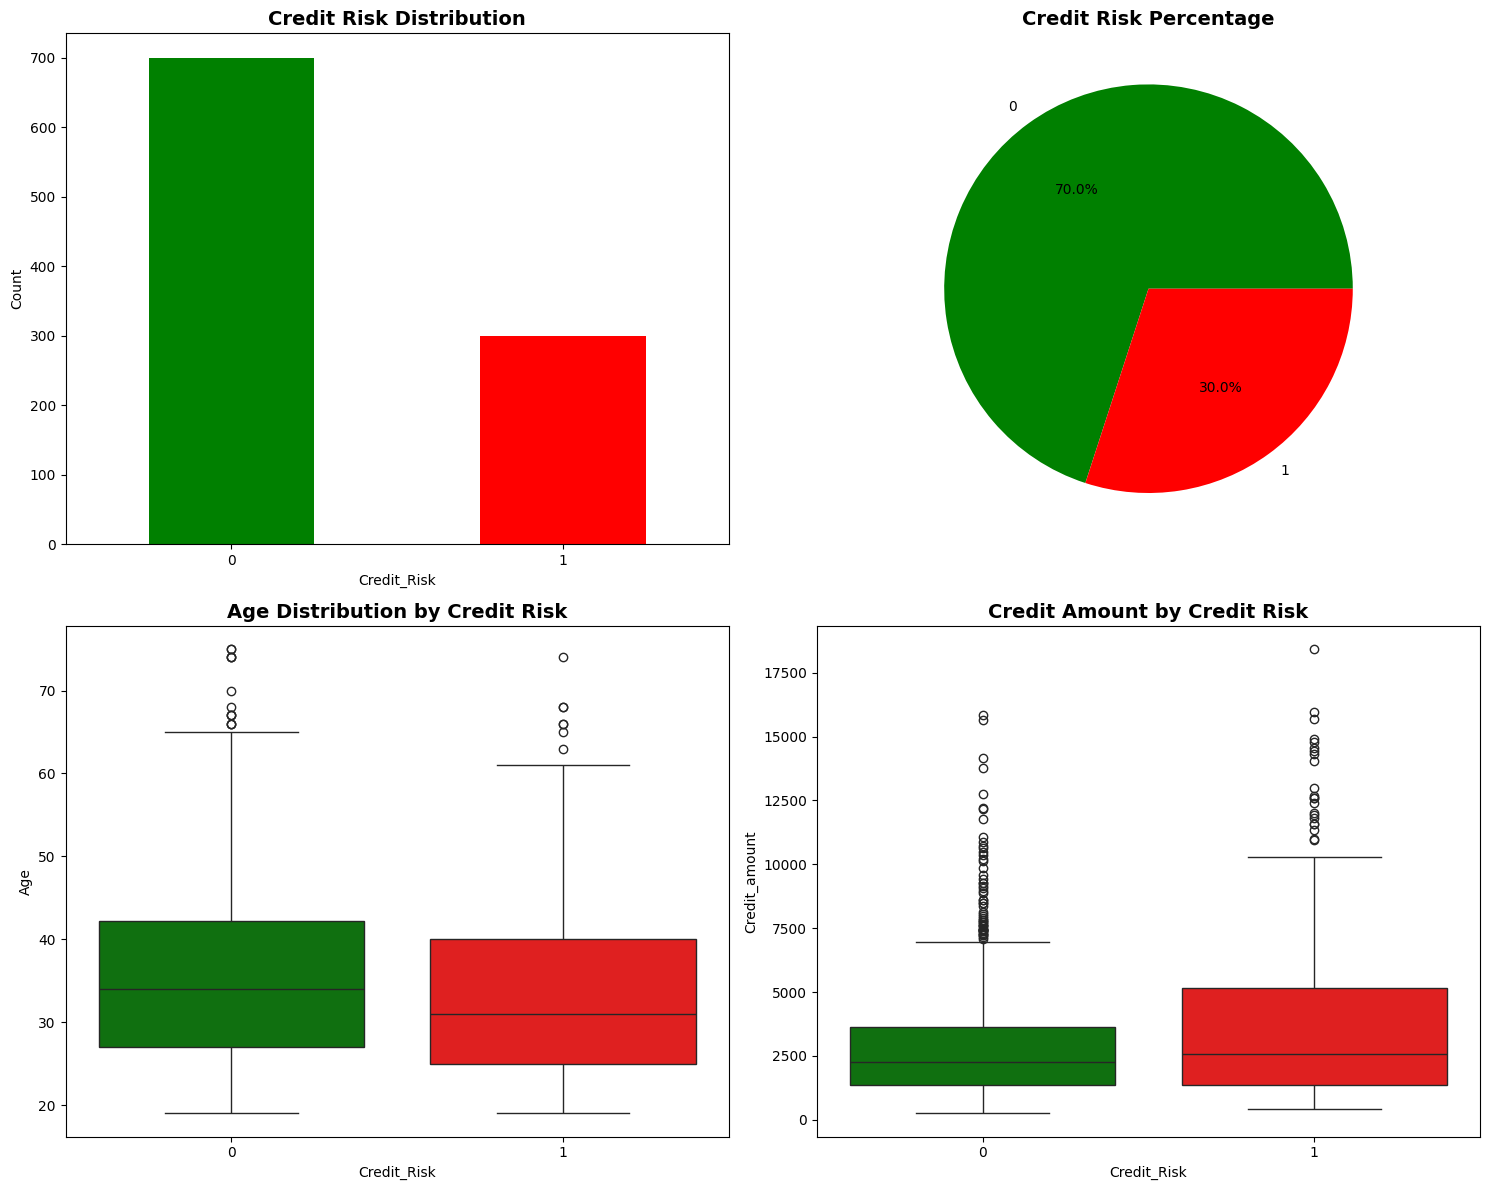

 EDA complete! Saved: eda_visualizations.png

🔧 Feature Engineering...
 Preprocessing complete!
Total features: 20
Feature types:
float64    20
int64       1
Name: count, dtype: int64

 Train-Test Split:
Training set: (800, 20)
Test set: (200, 20)

 Training 3 models...
Training Logistic Regression...
  → AUC: 0.790, F1: 0.577
Training Decision Tree...
  → AUC: 0.617, F1: 0.496
Training Random Forest...
  → AUC: 0.778, F1: 0.515

 BEST MODEL: Logistic Regression
   AUC: 0.790
   Precision: 0.627
   Recall: 0.533
   F1-Score: 0.577

 Creating evaluation plots...


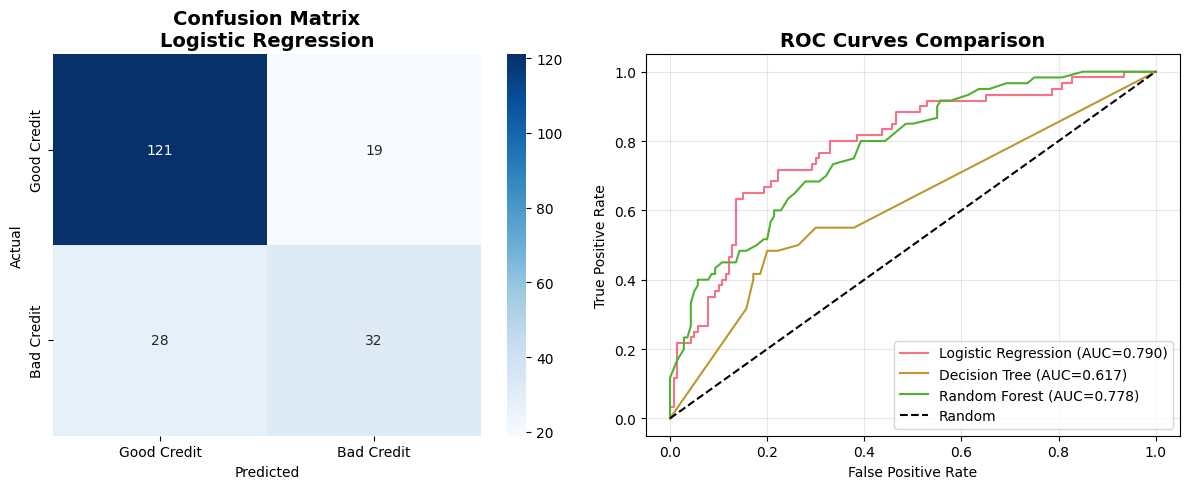

 Saved: model_evaluation.png


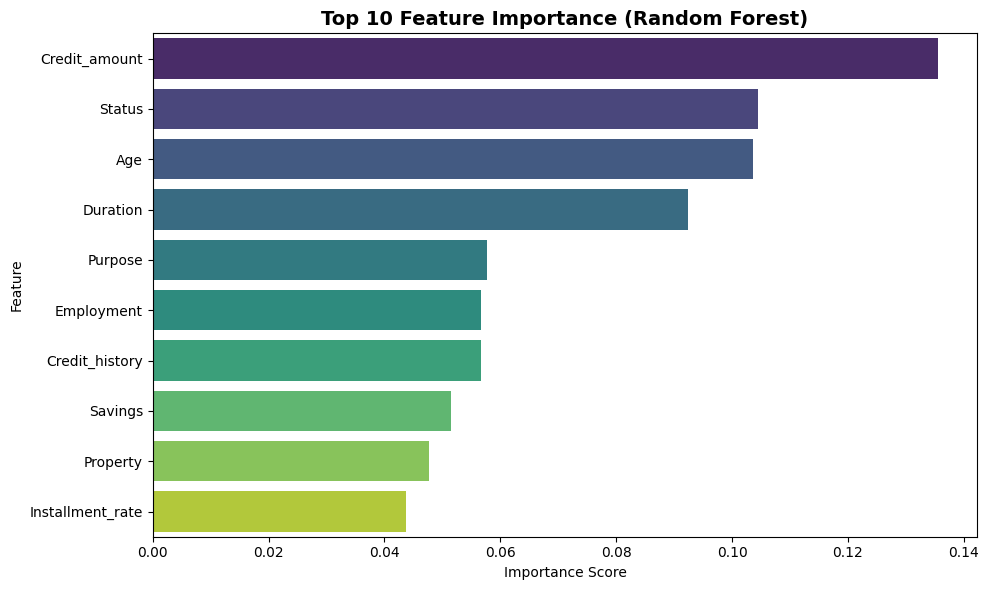


 TOP 5 MOST IMPORTANT FEATURES:
          Feature  Importance
4   Credit_amount    0.135560
0          Status    0.104528
12            Age    0.103649
1        Duration    0.092479
3         Purpose    0.057672

 Saving model files...
 Model saved successfully!
 Prediction function ready!

 SAMPLE PREDICTION:
Risk:  HIGH RISK (Bad Credit)
Bad Credit Probability: 0.634

 CREDIT SCORING MODEL 
Dataset: German Credit Dataset (1000 samples)
Features: 20
Target: Credit Risk (0=Good, 1=Bad)
Train/Test Split: 80/20

 BEST MODEL: Logistic Regression
   AUC-ROC: 0.790
   Precision: 0.627
   Recall: 0.533
   F1-Score: 0.577

 ALL MODELS COMPARISON:
                          AUC Precision    Recall        F1
Logistic Regression  0.790119  0.627451  0.533333  0.576577
Decision Tree        0.617381  0.508772  0.483333  0.495726
Random Forest        0.778333  0.675676  0.416667  0.515464

 FILES GENERATED:
   • credit_scoring_model.pkl (Trained model)
   • credit_scaler.pkl (Scaler)
   • label_enc

In [4]:

import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_fscore_support)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
print("All libraries imported successfully!")

print("\n Loading German Credit Dataset (1000 samples)...")


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
column_names = [
    'Status', 'Duration', 'Credit_history', 'Purpose', 'Credit_amount',
    'Savings', 'Employment', 'Installment_rate', 'Status_sex',
    'Other_debtors', 'Residence_duration', 'Property', 'Age',
    'Other_installment', 'Housing', 'Num_credits', 'Job',
    'Num_people', 'Telephone', 'Foreign', 'Credit_risk'
]

df = pd.read_csv(url, sep=' ', names=column_names)
df['Credit_Risk'] = df['Credit_risk'].map({1: 0, 2: 1})  # 0=Good, 1=Bad
df = df.drop('Credit_risk', axis=1)

print(f" Dataset loaded!")
print(f"Shape: {df.shape}")
print("\nTarget Distribution:")
print(df['Credit_Risk'].value_counts())
print(f"\nDataset preview:")
print(df.head())


print("\n Generating EDA visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

df['Credit_Risk'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Credit Risk Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

df['Credit_Risk'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0,1],
                                     colors=['green','red'])
axes[0,1].set_title('Credit Risk Percentage', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('')

sns.boxplot(data=df, x='Credit_Risk', y='Age', ax=axes[1,0], palette=['green','red'])
axes[1,0].set_title('Age Distribution by Credit Risk', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='Credit_Risk', y='Credit_amount', ax=axes[1,1], palette=['green','red'])
axes[1,1].set_title('Credit Amount by Credit Risk', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print(" EDA complete! Saved: eda_visualizations.png")

print("\n🔧 Feature Engineering...")

categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

scaler = StandardScaler()
numeric_features = df.select_dtypes(include=[np.number]).columns.drop('Credit_Risk')
df[numeric_features] = scaler.fit_transform(df[numeric_features])

print(f" Preprocessing complete!")
print(f"Total features: {len(numeric_features)}")
print("Feature types:")
print(df.dtypes.value_counts())

X = df.drop('Credit_Risk', axis=1)
y = df['Credit_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Train-Test Split:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


print("\n Training 3 models...")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

    results[name] = {
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Model': model
    }
    predictions[name] = y_proba

    print(f"  → AUC: {auc:.3f}, F1: {f1:.3f}")

best_model_name = max(results.keys(), key=lambda k: results[k]['AUC'])
best_result = results[best_model_name]
best_model = models[best_model_name]

print(f"\n BEST MODEL: {best_model_name}")
print(f"   AUC: {best_result['AUC']:.3f}")
print(f"   Precision: {best_result['Precision']:.3f}")
print(f"   Recall: {best_result['Recall']:.3f}")
print(f"   F1-Score: {best_result['F1']:.3f}")


print("\n Creating evaluation plots...")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Credit', 'Bad Credit'],
            yticklabels=['Good Credit', 'Bad Credit'])
plt.title(f'Confusion Matrix\n{best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 2, 2)
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, predictions[name])
    auc_score = result['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: model_evaluation.png")


if 'Random Forest' in models:
    rf_model = models['Random Forest']
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 10 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n TOP 5 MOST IMPORTANT FEATURES:")
    print(importance_df.head())


print("\n Saving model files...")

joblib.dump(best_model, 'credit_scoring_model.pkl')
joblib.dump(scaler, 'credit_scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

def predict_credit_risk(new_data):
    """
    Predict credit risk for new customer
    new_data: DataFrame with same columns as training data
    Returns: (risk_level, probability)
    """
    model = joblib.load('credit_scoring_model.pkl')
    scaler_loaded = joblib.load('credit_scaler.pkl')

    new_data_scaled = scaler_loaded.transform(new_data)
    prediction = model.predict(new_data_scaled)[0]
    probability = model.predict_proba(new_data_scaled)[0, 1]

    risk_level = " LOW RISK (Good Credit)" if prediction == 0 else " HIGH RISK (Bad Credit)"
    return risk_level, probability

print(" Model saved successfully!")
print(" Prediction function ready!")

sample_customer = X_test.iloc[0:1]
risk, prob = predict_credit_risk(sample_customer)
print(f"\n SAMPLE PREDICTION:")
print(f"Risk: {risk}")
print(f"Bad Credit Probability: {prob:.3f}")

print("\n" + "="*60)
print(" CREDIT SCORING MODEL ")
print("="*60)
print(f"Dataset: German Credit Dataset (1000 samples)")
print(f"Features: {X.shape[1]}")
print(f"Target: Credit Risk (0=Good, 1=Bad)")
print(f"Train/Test Split: 80/20")
print(f"\n BEST MODEL: {best_model_name}")
print(f"   AUC-ROC: {best_result['AUC']:.3f}")
print(f"   Precision: {best_result['Precision']:.3f}")
print(f"   Recall: {best_result['Recall']:.3f}")
print(f"   F1-Score: {best_result['F1']:.3f}")

results_df = pd.DataFrame(results).T[['AUC', 'Precision', 'Recall', 'F1']]
print(f"\n ALL MODELS COMPARISON:")
print(results_df.round(3))

print("\n FILES GENERATED:")
print("   • credit_scoring_model.pkl (Trained model)")
print("   • credit_scaler.pkl (Scaler)")
print("   • label_encoders.pkl (Encoders)")
print("   • eda_visualizations.png")
print("   • model_evaluation.png")
print("   • feature_importance.png")
print("\n READY FOR GITHUB & LINKEDIN POST!")
print("="*60)

print("\n FINAL RESULTS TABLE:")
print(results_df.style.background_gradient(cmap='viridis').to_string())